# Week 4 – ETS(A,Ad,N) Time Series Forecasting

The objective of this section is to forecast future CO₂ emissions using a classical time-series forecasting model.
Unlike the supervised machine learning models developed in Week 3, this approach uses only the historical emission values to learn the underlying trend.
The Exponential Smoothing model provides an interpretable forecasting baseline that is suitable for annual environmental time-series data.

### ETS(A,Ad,N)

ETS represents Error, Trend and Seasonality.

• Error (A): Additive error assumes that random forecasting errors are added to the model.

• Trend (Ad): Additive damped trend models long-term growth while gradually reducing the trend through the damping parameter.

• Seasonality (N): No seasonal component is included because annual emissions data contain no within-year seasonal cycle.

ETS(A,Ad,N) is well suited to annual greenhouse gas emissions because it provides stable long-term forecasts without producing unrealistic exponential growth.

In [75]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [76]:
df = pd.read_csv("data/filtered_dataset.csv")
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Australia,1990,AUS,17126304.0,4.641366e+11,3.463,0.202,278.061,21.223,8.263,...,0.666,1.693,0.007,0.008,0.017,0.002,538.479,336.927,-33.380,-12.005
1,Australia,1991,AUS,17353191.0,4.613021e+11,3.183,0.183,279.437,1.376,0.495,...,0.643,1.687,0.007,0.008,0.017,0.002,522.525,339.829,-34.011,-12.171
2,Australia,1992,AUS,17549286.0,4.786337e+11,2.923,0.167,284.433,4.996,1.788,...,0.699,1.680,0.007,0.008,0.017,0.002,568.962,346.607,-36.367,-12.786
3,Australia,1993,AUS,17722905.0,5.015248e+11,3.005,0.170,288.780,4.347,1.528,...,0.810,1.677,0.007,0.008,0.017,0.002,580.666,350.855,-40.004,-13.853
4,Australia,1994,AUS,17897433.0,5.279932e+11,3.484,0.195,293.613,4.833,1.674,...,0.924,1.671,0.007,0.008,0.018,0.002,554.084,353.411,-35.667,-12.148


In [77]:
country = "India"
country_df = (
    df[df["country"] == country]
    .sort_values("year")
    .reset_index(drop=True)
)
country_df[["year","co2"]].head()

,year,co2
0,1990,577.987
1,1991,615.388
2,1992,655.424
3,1993,677.262
4,1994,714.043


The forecasting model is first demonstrated using India.
The historical CO₂ emissions are sorted chronologically before fitting the forecasting model.

In [78]:
model_data = pd.read_csv("data/model_data.csv")
ets = model_data [["country","year","co2"]].copy()
ets.head()

,country,year,co2
0,Australia,1993,288.780
1,Australia,1994,293.613
2,Australia,1995,304.962
3,Australia,1996,311.851
4,Australia,1997,320.243


### Interpretation of ETS Parameters

The damping parameter (phi) controls how quickly the long-term trend slows down. A value close to one indicates that the trend continues for longer, while a lower value indicates stronger damping and a gradual flattening of future emissions.

In [79]:
ets_models = {}
ets_parameters = []
for country in ets["country"].unique():
    country_df = (ets[ets["country"] == country].sort_values("year"))
    train = country_df[country_df["year"] <= 2018]
    test = country_df[country_df["year"] >= 2019]
    train_series = train.set_index("year")["co2"]
    test_series = test.set_index("year")["co2"]
    
    model_ets = ExponentialSmoothing(
        train_series,
        trend="add",
        seasonal=None,
        damped_trend=True
    )
    fit= model_ets.fit(optimized=True)
    ets_models[country] = fit
    ets_parameters.append({
        "Country":country,
        "Alpha":fit.params["smoothing_level"],
        "Beta":fit.params["smoothing_trend"],
        "Phi":fit.params["damping_trend"]
    })
ets_parameters = pd.DataFrame( ets_parameters)
ets_parameters        

,Country,Alpha,Beta,Phi
0,Australia,1.000000e+00,0.000000e+00,0.931651
1,Brazil,1.000000e+00,0.000000e+00,0.955967
2,China,1.000000e+00,8.634193e-01,0.867771
3,Germany,1.490116e-08,1.042255e-08,0.995000
4,India,6.410137e-01,6.410137e-01,0.995000
5,Japan,1.000000e+00,0.000000e+00,0.800000
6,Russia,4.662360e-01,4.662360e-01,0.800000
7,South Africa,7.177577e-01,0.000000e+00,0.907136
8,United Kingdom,5.306912e-01,3.513540e-01,0.995000
9,United States,6.961325e-01,1.765632e-01,0.819795


An additive trend with damping is used because the annual CO₂ series does not exhibit seasonality, while long-term growth is expected to gradually slow over time.

In [80]:
forecast_test = []
steps = 20 
years = range(2024, 2024 + steps)
for country, fit in ets_models.items():

    forecast = fit.forecast(steps=steps)
    
    # Monte Carlo Simulation
    simulations = fit.simulate(
        nsimulations=steps,
        repetitions=1000
    )
    simulations = pd.DataFrame(simulations)

    lower_ci = simulations.quantile(0.025, axis=1)
    upper_ci = simulations.quantile(0.975, axis=1)
    
    for year, pred, low, high in zip(
        years,
        forecast,
        lower_ci,
        upper_ci
    ):
        forecast_test.append({
        "country": country,
        "Year": year,
        "Forecast_CO2": pred,
        "Lower_95CI": low,
        "Upper_95CI": high
    })
forecast_test =  pd.DataFrame(forecast_test)
forecast_test.head()

,country,Year,Forecast_CO2,Lower_95CI,Upper_95CI
0,Australia,2024,416.581363,407.427436,426.007985
1,Australia,2025,418.258674,406.173009,431.299273
2,Australia,2026,419.821343,404.198855,434.675916
3,Australia,2027,421.277205,402.453486,438.859716
4,Australia,2028,422.633562,401.544247,443.549762


In [81]:
forecast_test[ forecast_test["country"] == "India"]

,country,Year,Forecast_CO2,Lower_95CI,Upper_95CI
80,India,2024,2693.111397,2624.647770,2763.355538
81,India,2025,2812.234152,2702.668392,2918.231572
82,India,2026,2930.761294,2761.935712,3101.904783
83,India,2027,3048.695800,2804.551839,3292.261945
84,India,2028,3166.040633,2824.750461,3497.586258
85,India,2029,3282.798742,2839.534471,3698.875210
86,India,2030,3398.973060,2854.813911,3913.175695
87,India,2031,3514.566507,2867.870197,4146.779832
88,India,2032,3629.581987,2842.577658,4371.209224
89,India,2033,3744.022389,2822.266708,4623.216047


In [82]:
forecast_test.to_csv("data/forecast_test.csv",index=False)
forecast_test.head()

,country,Year,Forecast_CO2,Lower_95CI,Upper_95CI
0,Australia,2024,416.581363,407.427436,426.007985
1,Australia,2025,418.258674,406.173009,431.299273
2,Australia,2026,419.821343,404.198855,434.675916
3,Australia,2027,421.277205,402.453486,438.859716
4,Australia,2028,422.633562,401.544247,443.549762


## Forecast Visualization

The following figure compares historical emissions with forecasted future emissions.

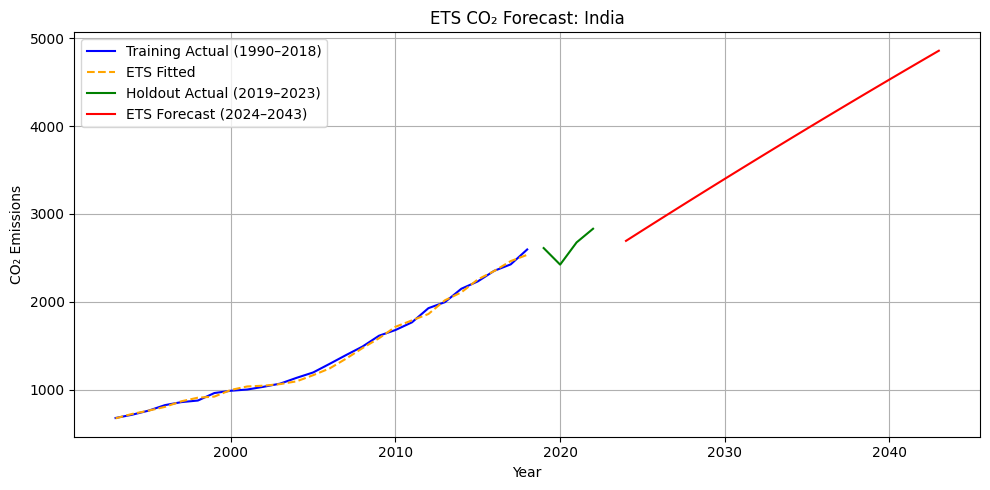

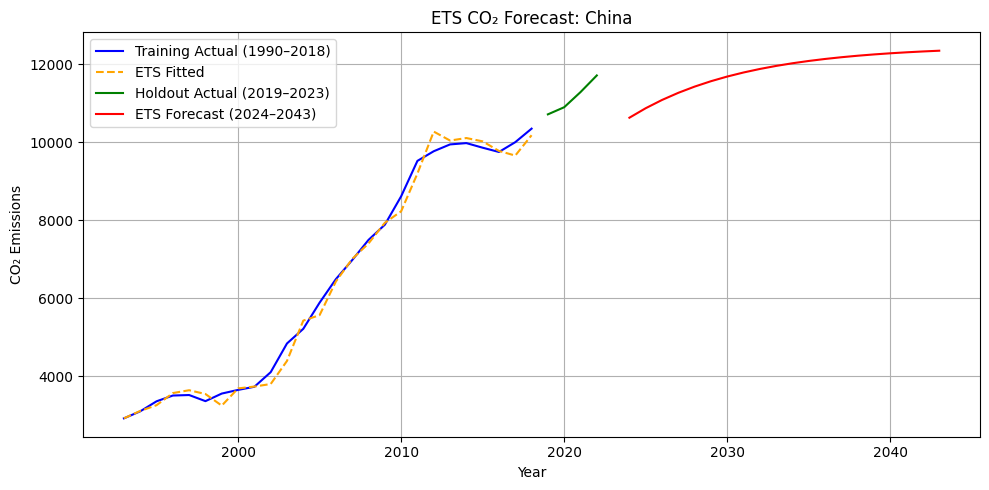

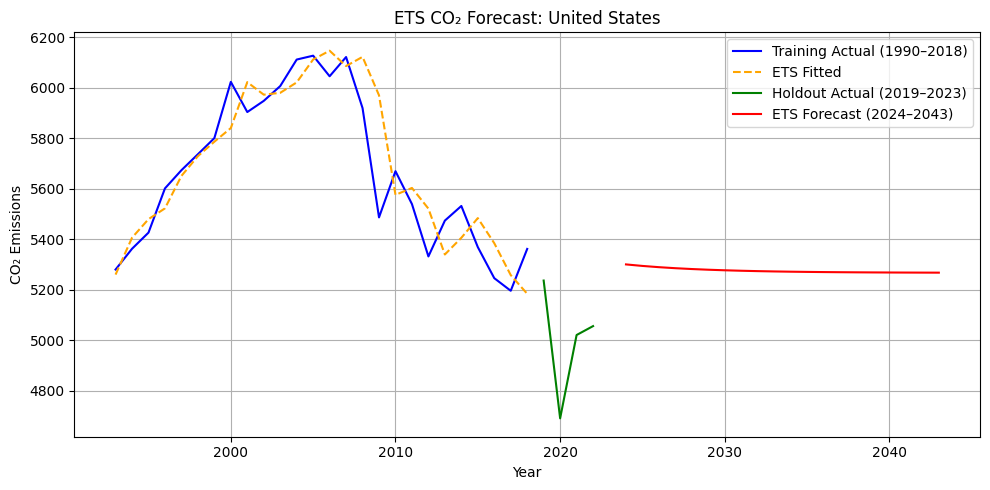

In [83]:
plot_forecast_test = ["India", "China", "United States"]
for country in plot_forecast_test:

    country_df = (ets[ets["country"] == country].sort_values("year"))
    train = country_df[country_df["year"] <= 2018]
    test = country_df[country_df["year"] >= 2019]

    fitted = ets_models[country].fittedvalues

    forecast = forecast_test[forecast_test["country"] == country]

    plt.figure(figsize=(10, 5))

    # Training data
    plt.plot(
        train["year"],
        train["co2"],
        label="Training Actual (1990–2018)",
        color="blue"
    )
    # ETS fitted values
    plt.plot(
        train["year"],
        fitted.values,
        label="ETS Fitted",
        linestyle="--",
        color="orange"
    )
    # Holdout data
    plt.plot(
        test["year"],
        test["co2"],
        label="Holdout Actual (2019–2023)",
        color="green"
    )
    # Forecast
    plt.plot(
        forecast["Year"],
        forecast["Forecast_CO2"],
        label="ETS Forecast (2024–2043)",
        color="red"
    )
    plt.title(f"ETS CO₂ Forecast: {country}")
    plt.xlabel("Year")
    plt.ylabel("CO₂ Emissions")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    

In [84]:
forecast_summary = (
    forecast_test[forecast_test["Year"].isin([2030,2035,2040])])
forecast_summary.head()

,country,Year,Forecast_CO2,Lower_95CI,Upper_95CI
6,Australia,2030,425.074495,400.229185,450.058332
11,Australia,2035,429.858431,396.524668,458.870189
16,Australia,2040,433.216213,394.312450,466.380321
26,Brazil,2030,507.401053,402.952015,616.158801
31,Brazil,2035,524.158231,399.314635,664.482463


In [85]:
# Forecast summary for selected years
forecast_summary = (
    forecast_test[
        forecast_test["Year"].isin([2030, 2035, 2040])])
forecast_summary = forecast_summary.pivot(
    index="country",
    columns="Year",
    values="Forecast_CO2"
)
forecast_summary.columns = ["2030", "2035", "2040"]
forecast_summary = forecast_summary.reset_index()
# Get actual CO2 for 2020
actual_2020 = (
    df[df["year"] == 2020][["country", "co2"]]
    .rename(columns={"co2": "2020 Actual"})
)
# Merge actual and forecast
forecast_summary = forecast_summary.merge(
    actual_2020,
    on="country",
    how="left"
)
# Percentage change from 2020 to 2040
forecast_summary["% Change 2020→2040"] = (
    (
        forecast_summary["2040"]
        - forecast_summary["2020 Actual"]
    )
    / forecast_summary["2020 Actual"]
) * 100
# Round values
forecast_summary = forecast_summary.round(2)
# Arrange columns
forecast_summary = forecast_summary[
    [
        "country",
        "2020 Actual",
        "2030",
        "2035",
        "2040",
        "% Change 2020→2040"
    ]
]
forecast_summary

,country,2020 Actual,2030,2035,2040,% Change 2020→2040
0,Australia,398.55,425.07,429.86,433.22,8.70
1,Brazil,448.00,507.40,524.16,537.54,19.99
2,China,10896.52,11683.93,12083.74,12280.47,12.70
3,Germany,647.18,722.49,688.34,655.04,1.21
4,India,2422.73,3398.97,3971.19,4529.24,86.95
5,Japan,1037.29,1138.93,1138.99,1139.02,9.81
6,Russia,1631.90,1722.41,1730.89,1733.67,6.24
7,South Africa,435.30,458.52,461.12,462.71,6.30
8,United Kingdom,326.26,262.29,184.58,108.80,-66.65
9,United States,4689.95,5276.57,5270.18,5267.81,12.32


## Forecast Interpretation

The Exponential Smoothing model provides country-level projections of future CO₂ emissions based on historical trends from 1990–2018.
India is projected to continue increasing emissions over the forecast horizon, although the damping effect gradually slows the rate of growth.
China shows signs of slower long-term growth compared with the historical period as the forecast trend becomes more stable.
The United Kingdom continues a declining trajectory that is consistent with historical emissions reductions and climate policy changes.
These forecasts represent trend-based projections and do not include future policy changes, technological improvements, or unexpected global events.

In [86]:
forecast_summary.to_csv(
    "data/forecast_summary.csv",
    index=False
)
print("Forecast Summary Saved")

Forecast Summary Saved


In [87]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
ets_validation = []
for country in ets["country"].unique():
    country_df = (
        ets[ets["country"] == country]
        .sort_values("year")
    )
    train = country_df[country_df["year"] <= 2018]
    test = country_df[country_df["year"] >= 2019]

    train_series = train.set_index("year")["co2"]
    test_series = test.set_index("year")["co2"]

    model = ExponentialSmoothing(
        train_series,
        trend="add",
        damped_trend=True,
        seasonal=None
    )
    fitted = model.fit(optimized=True)
    # Forecast only the holdout period (2019–2023)
    forecast = fitted.forecast(steps=len(test_series))

    mae = mean_absolute_error(test_series, forecast)
    rmse = root_mean_squared_error(test_series, forecast)

    ets_validation.append({
        "Country": country,
        "MAE": mae,
        "RMSE": rmse
    })
ets_validation = pd.DataFrame(ets_validation)
ets_validation = ets_validation.round(3)
ets_validation

,Country,MAE,RMSE
0,Australia,22.479,26.258
1,Brazil,16.048,21.007
2,China,189.422,248.436
3,Germany,78.565,81.019
4,India,235.996,260.181
5,Japan,81.871,86.594
6,Russia,36.699,40.575
7,South Africa,19.959,20.452
8,United Kingdom,10.019,11.875
9,United States,291.515,351.302


Forecast accuracy is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). Lower values indicate better forecasting performance.

In [88]:
future_forecast = fitted.forecast(steps=20)
future_years = np.arange(2019,2019 + 20)
forecast_df = pd.DataFrame({
    "Year": future_years,
    "Forecast_CO2": future_forecast
})
forecast_df

,Year,Forecast_CO2
2019,2019,5299.863851
2020,2020,5293.836763
2021,2021,5288.895785
2022,2022,5284.845195
2023,2023,5281.524541
2024,2024,5278.802284
2025,2025,5276.570592
2026,2026,5274.741061
2027,2027,5273.241221
2028,2028,5272.011659


In [89]:
forecast_df.to_csv(
    "data/india_forecast.csv",
    index=False
)
print("Forecast Saved")

Forecast Saved


Saving Forecast Results
The forecasted CO₂ emissions were exported to a CSV file for future analysis and comparison with machine learning models.

The forecasted annual CO₂ emissions are exported for future analysis and comparison.

In [90]:
forecast_df.round(2)

,Year,Forecast_CO2
2019,2019,5299.86
2020,2020,5293.84
2021,2021,5288.90
2022,2022,5284.85
2023,2023,5281.52
2024,2024,5278.80
2025,2025,5276.57
2026,2026,5274.74
2027,2027,5273.24
2028,2028,5272.01


Interpretation
The Exponential Smoothing model projects future CO₂ emissions by extending the historical trend observed between 1990 and 2018.
The forecast indicates the expected direction of future emissions while gradually damping long-term growth. This provides an interpretable baseline forecasting model for comparison with future machine learning and deep learning approaches.

In [91]:
check = pd.read_csv("data/india_forecast.csv")
check.head()
check.shape

(20, 2)

In [92]:
summary = pd.DataFrame({
    "Metric":[
        "Training Years",
        "Testing Years",
        "Forecast Horizon",
        "Model"
    ],
    "Value":[
        "1990-2018",
        "2019-2023",
        "20 Years",
        "Exponential Smoothing"
    ]
})
summary

,Metric,Value
0,Training Years,1990-2018
1,Testing Years,2019-2023
2,Forecast Horizon,20 Years
3,Model,Exponential Smoothing


In [93]:
forecast_df.head(10)

,Year,Forecast_CO2
2019,2019,5299.863851
2020,2020,5293.836763
2021,2021,5288.895785
2022,2022,5284.845195
2023,2023,5281.524541
2024,2024,5278.802284
2025,2025,5276.570592
2026,2026,5274.741061
2027,2027,5273.241221
2028,2028,5272.011659


In [94]:
forecast_df.tail()

,Year,Forecast_CO2
2034,2034,5268.116022
2035,2035,5267.810045
2036,2036,5267.559207
2037,2037,5267.353572
2038,2038,5267.184992


In [95]:
forecast_df.describe()

,Year,Forecast_CO2
count,20.00000,20.000000
mean,2028.50000,5275.523573
std,5.91608,9.601776
min,2019.00000,5267.184992
25%,2023.75000,5268.395948
50%,2028.50000,5271.507664
75%,2033.25000,5279.482849
max,2038.00000,5299.863851


## Week 4 Summary

The Exponential Smoothing model was used to forecast future CO₂ emissions based solely on historical emission values. Unlike the supervised machine learning models developed in Week 3, this forecasting approach does not require engineered features and instead models the underlying time-series trend directly.
The model was trained using observations from 1990–2018 and evaluated on data from 2019–2023 using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). Future emissions were then projected for the next twenty years.
The forecasting results provide a useful baseline for understanding long-term emission patterns and can support climate policy analysis and future environmental planning.